# Program - modify-DYCOMSrf01_rf02-IC_4scam.ipynb

**Purpose**
Modify DYCOMS RF01 and RF02 SCM input

**Content**
- compute profiles from references
- plot XY profiles

**Author:** Yi-Hsuan Chen (yihsuan@umich.edu)

**Date:** 
May 2025

**Reference program:**



In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import io, os, sys, types

import yhc_module as yhc

xr.set_options(keep_attrs=True)  # keep attributes after xarray operation

ERROR 1: PROJ: proj_create_from_database: Open of /lfs/opt/anaconda3/share/proj failed


# Functions

## theta_l_to_T_qv_ql

In [2]:
import numpy as np

# Constants
Rd = 287.04       # gas constant for dry air (J/kg/K)
Rv = 461.5        # gas constant for water vapor (J/kg/K)
Cp = 1005.7       # specific heat of dry air at constant pressure (J/kg/K)
Lv = 2.5e6        # latent heat of vaporization (J/kg)
epsilon = Rd / Rv

def saturation_vapor_pressure(T):
    """Calculate saturation vapor pressure over liquid water (Pa)"""
    T = np.asarray(T)
    return 610.94 * np.exp((17.625 * (T - 273.15)) / (T - 30.11))

def saturation_specific_humidity(p, T):
    """Compute saturation specific humidity (kg/kg)"""
    p = np.asarray(p)
    T = np.asarray(T)
    e_s = saturation_vapor_pressure(T)
    return epsilon * e_s / (p - (1 - epsilon) * e_s)

def theta_l_to_T_qv_ql(theta_l, q_t, p, tol=1e-6, max_iter=100):
    """
    Convert theta_l and q_t to T, q_v, and q_l using iterative saturation adjustment.

    Parameters:
        theta_l: liquid water potential temperature (K)
        q_t: total water mixing ratio (kg/kg)
        p: pressure (Pa)

    Returns:
        T: temperature (K)
        q_v: specific humidity (kg/kg)
        q_l: liquid water mixing ratio (kg/kg)
    """
    # Ensure array compatibility
    theta_l = np.asarray(theta_l)
    q_t = np.asarray(q_t)
    p = np.asarray(p)

    # Initial guess for T (assume no liquid water)
    T = theta_l * (p / 1e5) ** (Rd / Cp)

    alpha = 0.5  # damping factor between 0 (no update) and 1 (full update)

    for _ in range(max_iter):
        q_vs = saturation_specific_humidity(p, T)
        q_v = np.minimum(q_t, q_vs)
        q_l = np.maximum(q_t - q_vs, 0.0)

        T_update = theta_l * (p / 1e5) ** (Rd / Cp) + (Lv / Cp) * q_l
        T_new = (1 - alpha) * T + alpha * T_update
        #print("T, T_new", T, T_new)

        if np.all(np.abs(T_new - T) < tol):
            break

        T = T_new.copy()

    return T, q_v, q_l

#-----------
# do test
#-----------
do_test = "112"
if (do_test == "111"):
    theta_l = 289
    q_t = 20e-3
    p = 1000e2
    T, q_v, q_l = theta_l_to_T_qv_ql(theta_l, q_t, p)
    print(T, q_v, q_l)
    print(saturation_specific_humidity(p, T))

## RF01_IC_formula
Stevens, B., Moeng, C.-H., Ackerman, A. S., Bretherton, C. S., Chlond, A., de Roode, S., Edwards, J., Golaz, J. C., Jiang, H., Khairoutdinov, M., Kirkpatrick, M. P., Lewellen, D. C., Lock, A., Müller, F., Stevens, D. E., Whelan, E., & Zhu, P. (2005). Evaluation of large-eddy simulations via observations of nocturnal marine stratocumulus. Monthly Weather Review, 133(6), 1443–1462. https://doi.org/10.1175/MWR2930.1

In [3]:
def RF01_IC_formula(z, z_i=840, div=3.75e-6, p_surface=1017.8e2):
    """
    Compute theta_l, q_t, u, v, T, q_v, q_l profiles based on height array z and inversion height z_i.
    
    Parameters:
        z (array-like): 1D array of height values (in meters).
        z_i (float): Inversion height (in meters).
        p_surface (float): Surface pressure (in hPa).
        
    Returns:
        dict: Dictionary with keys 'theta_l', 'q_t', 'u', 'v', 'T', 'q_v', 'q_l'.
    """
    z = np.asarray(z)
    
    # Initialize theta_l with default value
    theta_l = np.full_like(z, 289.0, dtype=np.float64)
    above_zi = z > z_i
    theta_l[above_zi] = 297.5 + (z[above_zi] - z_i) ** (1/3)

    # Compute q_t
    q_t = np.where(z <= z_i, 9.0e-3, 1.5e-3)  # kg/kg

    # Constant wind profiles
    u = np.full_like(z, 6.0)       # m/s
    v = np.full_like(z, -4.25)     # m/s

    # Convert z (height) to pressure (p) using the hypsometric equation
    R = 287.05  # specific gas constant for dry air (J/kg·K)
    g = 9.81    # gravitational acceleration (m/s²)
    L = 2.5e6   # Latent heat of vaporization (J/kg)
    M = 28.97   # Molar mass of air (kg/mol)
    cp_air = 1005 # specific heat of air, units: J/kg/K
    T_surface = 289.0 * (p_surface/1000e2)**(R/cp_air) # Surface temperature (in Kelvin, example)

    # compute vertical velocity
    w = np.zeros_like(z, dtype=np.float64)
    p = np.zeros_like(z, dtype=np.float64)
    T = np.zeros_like(z, dtype=np.float64)
    q_v = np.zeros_like(z, dtype=np.float64)
    q_l = np.zeros_like(z, dtype=np.float64)
    omega = np.zeros_like(z, dtype=np.float64)

    # Integrate from top to bottom
    for i in range(1, len(z)):
        dz = z[i] - z[i - 1]
        w[i] = w[i - 1] - div * dz  # Minus sign from continuity equation    

    # surface properties
    T[0] = T_surface
    p[0] = p_surface
    q_v[0] = q_t[0]
    q_l[0] = 0

    # compute pressure levels
    for i in range(1, len(z)):
        T[i] = T[i-1]
        dz = z[i] - z[i - 1]
        p[i] = p[i-1] * np.exp(-(g * dz) / (R * T[i]))
        #print(theta_l[i], q_t[i], p[i])
        T[i], q_v[i], q_l[i] = theta_l_to_T_qv_ql(theta_l[i], q_t[i], p[i])
        #omega[i] = -p[i]*g / (R * T[i]) * w[i]
        #print(T[i], q_v[i], q_l[i])

    for i in range(1, len(z)):
        dp = p[i] - p[i - 1]
        omega[i] = omega[i - 1] - div * dp  # Minus sign from continuity equation    
    
    # Build xarray dataset
    ds = xr.Dataset(
        data_vars=dict(
            theta_l=(["z"], theta_l, {"units": "K", "long_name": "Liquid Water Potential Temperature"}),
            q_t=(["z"], q_t, {"units": "kg/kg", "long_name": "Total Water Mixing Ratio"}),
            u=(["z"], u, {"units": "m/s", "long_name": "Zonal Wind"}),
            v=(["z"], v, {"units": "m/s", "long_name": "Meridional Wind"}),
            w=(["z"], w, {"units": "m/s", "long_name": "Vertical Velocity"}),
            p=(["z"], p, {"units": "Pa", "long_name": "Pressure"}),
            T=(["z"], T, {"units": "K", "long_name": "Temperature"}),
            q_v=(["z"], q_v, {"units": "kg/kg", "long_name": "Water Vapor Mixing Ratio"}),
            q_l=(["z"], q_l, {"units": "kg/kg", "long_name": "Liquid Water Mixing Ratio"}),
            omega=(["z"], omega, {"units": "Pa/s", "long_name": "Vertical pressure velocity"}),
        ),
        coords=dict(
            z=(["z"], z, {"units": "m", "long_name": "Height"})
        ),
        attrs=dict(
            description="RF01 Initial Condition Profile"
        )
    )
    
    return ds
    
# Example usage:
#z = np.linspace(0, 2000, 500)
z = np.arange(0,3000,5)
ds_rf01 = RF01_IC_formula(z)
#ds_rf01

## (outdates) plot_profiles_from_ds

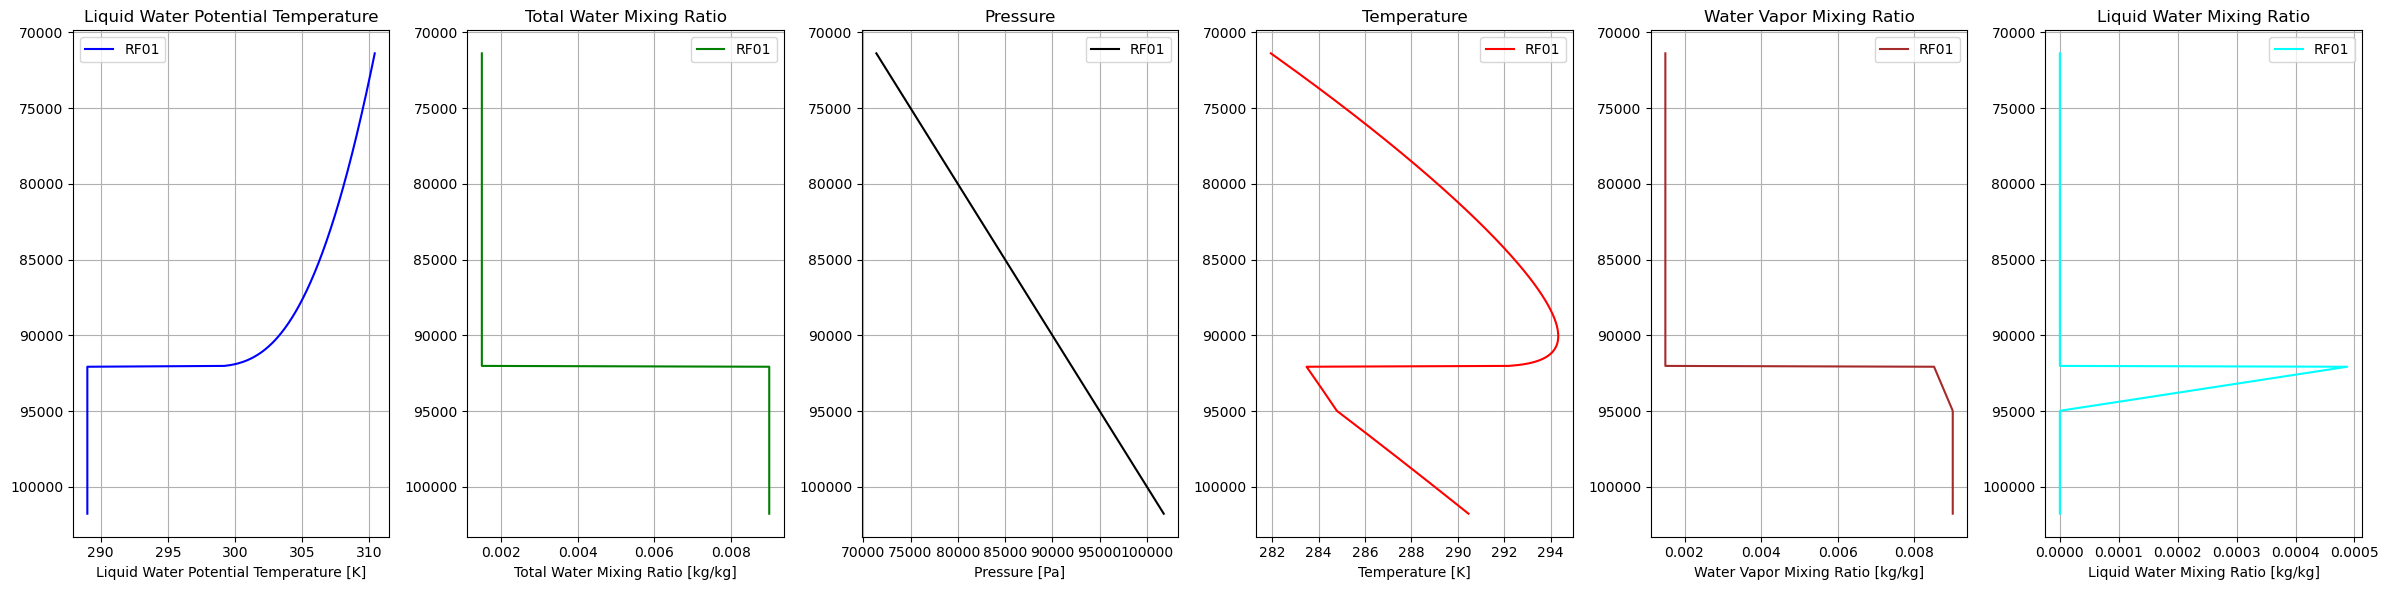

In [4]:
import matplotlib.pyplot as plt

def plot_profiles_from_ds(axes, ds, lg_label, yy='z',
                          keys_to_plot=['theta_l', 'q_t', 'u', 'v', 'w', 'T'],
                          marker=None):
    """
    Plot selected profiles from an xarray.Dataset.

    Parameters:
        axes (list): List of matplotlib axes to plot on.
        ds (xarray.Dataset): Dataset containing the variables to plot.
        lg_label (str): Label for the legend.
        keys_to_plot (list): List of variable names to plot.
        marker (str, optional): Marker style for the lines.
    """
    # Define a dictionary for colors
    colors = {
        'theta_l': 'blue',
        'q_t': 'green',
        'u': 'purple',
        'v': 'orange',
        'w': 'gray',
        'T': 'red',
        'q_v': 'brown',
        'q_l': 'cyan'
    }

    if (yy == "z" or yy == "lev"):
        lev = ds.coords[yy].values
    elif (yy == "p"):
        lev = ds[yy].values
    else:
        raise ValueError(f"Unexpected vertical coordinate: {yy}")

    for i, key in enumerate(keys_to_plot):
        if key not in ds:
            continue  # Skip if variable is missing
        field = ds[key].values
        label = ds[key].attrs.get('long_name', key)
        xlabel = f"{label} [{ds[key].attrs.get('units', '')}]"
        color = colors.get(key, 'black')

        axes[i].plot(field, lev, label=lg_label, color=color, marker=marker)
        axes[i].set_xlabel(xlabel)
        axes[i].set_title(label)
        axes[i].grid(True)
        axes[i].legend()

        if (yy == "p" or yy == "lev"):
            axes[i].invert_yaxis()

    plt.tight_layout()
    plt.show()

keys_to_plot=['theta_l', 'q_t', 'p', 'T', 'q_v','q_l']
#keys_to_plot=['u', 'v', 'w','omega']

num_keys = len(keys_to_plot)

# Create a figure with 4 subplots
fig, axes = plt.subplots(1, num_keys, figsize=(24, 6))
plot_profiles_from_ds (axes, ds_rf01, lg_label="RF01", yy='p', keys_to_plot=keys_to_plot)
#fields

## plot_profiles_from_multiple_ds

In [5]:
def plot_profiles_from_multiple_ds(axes, ds_list, lg_labels,
                                   yy_list, keys_to_plot_list,
                                   linestyles=['-'],
                                   markers=None):
    """
    Plot selected profiles from multiple xarray.Datasets on shared axes.

    Parameters:
        axes (list): List of matplotlib axes to plot on.
        ds_list (list of xarray.Dataset): Datasets to plot.
        lg_labels (list of str): Legend labels corresponding to each dataset.
        yy_list (list of str): Vertical coordinate keys for each dataset.
        keys_to_plot_list (list of list of str): Variable names to plot per dataset.
        markers (list of str, optional): Marker styles for each dataset.
    """
    import matplotlib.pyplot as plt

    # Define default colors (extend as needed)
    colors = {
        'theta_l': 'blue',
        'q_t': 'green',
        'u': 'purple',
        'v': 'orange',
        'w': 'gray',
        'T': 'red',
        'q_v': 'brown',
        'q_l': 'cyan'
    }

    num_ds = len(ds_list)
    if markers is None:
        markers = [None] * num_ds  # default: no marker

    for ds_idx, (ds, lg_label, yy, keys_to_plot) in enumerate(zip(ds_list, lg_labels, yy_list, keys_to_plot_list)):
        # Get vertical coordinate
        if yy in ds.coords:
            lev = ds.coords[yy].values
        elif yy in ds:
            lev = ds[yy].values
        else:
            raise ValueError(f"Unexpected vertical coordinate '{yy}' in dataset {ds_idx}")

        for key in keys_to_plot:
            if key not in ds:
                continue  # skip missing variables

            i = keys_to_plot.index(key)
            field = ds[key].values
            label = ds[key].attrs.get('long_name', key)
            xlabel = f"{label} [{ds[key].attrs.get('units', '')}]"
            color = colors.get(key, 'black')

            #print(lev)
            axes[i].plot(field, lev, label=lg_label, color=color, marker=markers[ds_idx], linestyle=linestyles[ds_idx])
            axes[i].set_xlabel(xlabel)
            axes[i].set_title(label)
            axes[i].grid(True)

            #if yy in ["p", "lev"]:
            #    axes[i].invert_yaxis()

    for ax in axes:
        ax.legend()
        if 'p' in yy_list:
            ax.invert_yaxis()
            #ax.set_ylim(800e2, 1020e2)

    plt.tight_layout()
    plt.show()


# RF01

## RF01 SCM input

In [6]:
filename = "./DYCOMSrf01_4day_4scam.nc"
ds_scm = xr.open_dataset(filename)
#ds_scm = yhc.diagnose_var(ds_scm, varnames = ["THETA_L","QT"])
ds_scm = ds_scm.isel(lon=0, lat=0, time=0)

# Print all variable names and their values
do_print = False
for var_name in ds_scm.data_vars:
    if (do_print):
        print(f"Variable: {var_name}")
        print(ds_scm[var_name].values)
        print("-" * 40)  # Separator for better readability        
#ds_scm

/lfs/opt/anaconda3/lib/python3.9/site-packages/xarray/coding/variables.py:214: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  condition |= data == fv
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


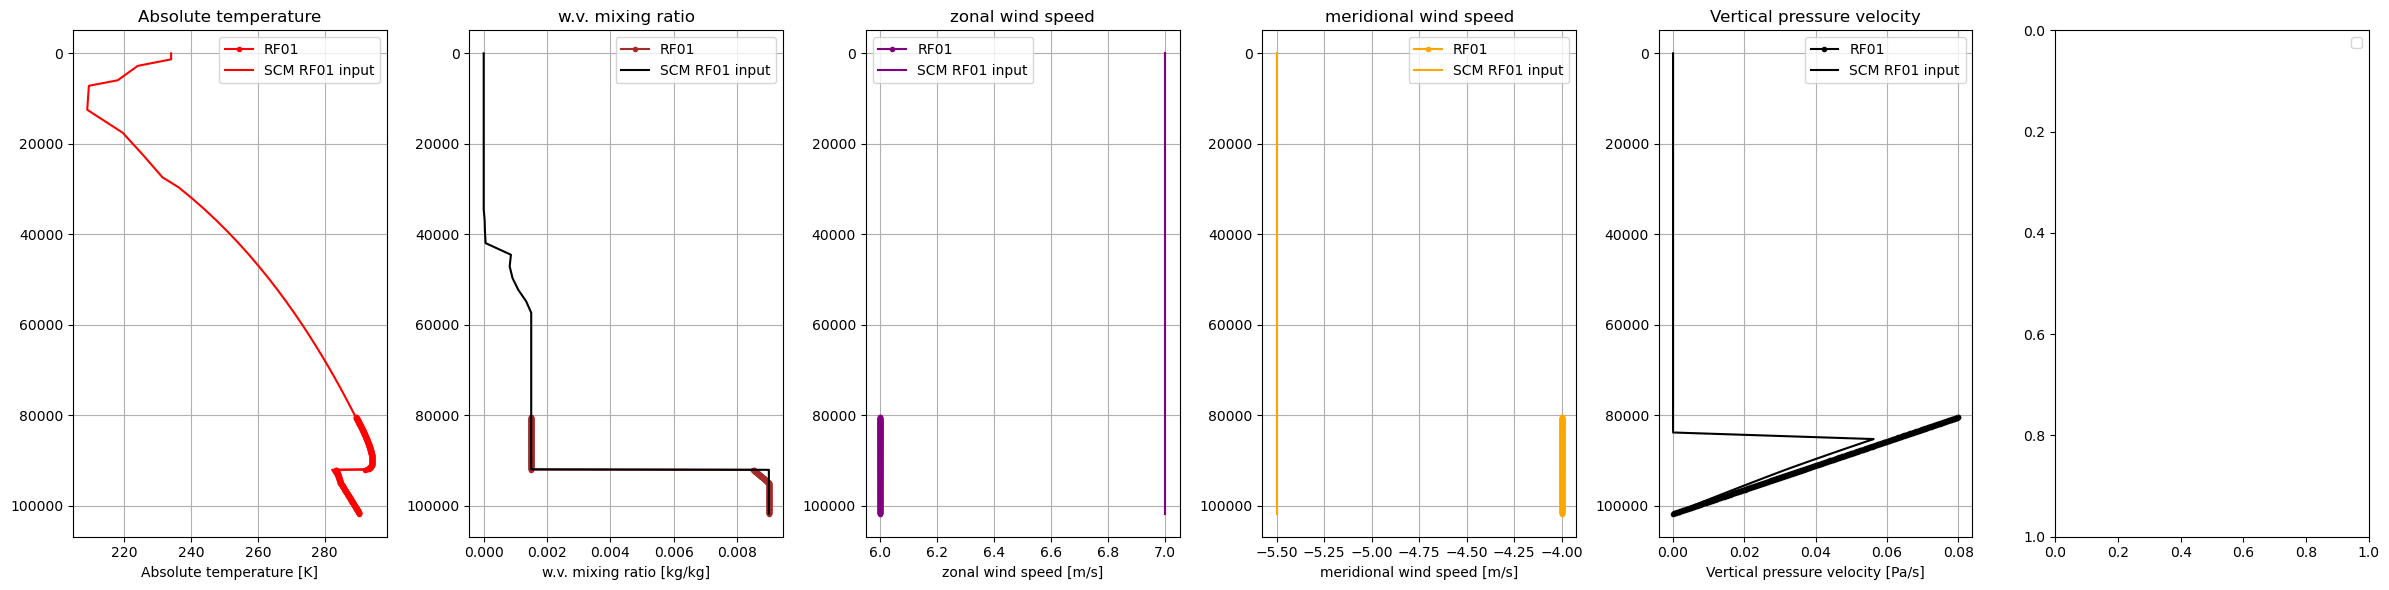

In [7]:
z = np.arange(0,2000,5)  # meters
ds_rf01 = RF01_IC_formula(z)

ds_list=[ds_rf01, ds_scm]
lg_labels=['RF01', 'SCM RF01 input']
yy_list=['p', 'lev']
keys_to_plot_list=[
    ['T', "q_v", 'u', 'v', 'omega'],   # for ds_rf01
    ['T', "q", 'u', 'v', 'omega']    # for ds_scm
]
linestyles=[None,'-']
markers=['.', None]

fig, axes = plt.subplots(1, num_keys, figsize=(24, 6))
plot_profiles_from_multiple_ds(axes, ds_list, lg_labels,
                                   yy_list, keys_to_plot_list,
                                   linestyles=linestyles, 
                                   markers=markers)